# Customer Segmentation Analysis using K-Means Clustering

## Objective

The objective of this project is to segment customers into different groups based on their Annual Income and Spending Score using the K-Means Clustering algorithm. This helps businesses understand customer behaviour and design targeted marketing strategies.

## Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df.shape

(200, 5)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [14]:
df.duplicated().sum()

np.int64(0)

## Observation

- Dataset contains 200 rows and 5 columns.
- No missing values were found.
- No duplicate records were found.
- Data types are appropriate for analysis.

In [15]:
df.rename(columns={"Genre": "Gender"}, inplace=True)

In [16]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
print("Average Purchase Value:", df["Annual Income (k$)"].mean())

Average Purchase Value: 60.56


In [18]:
print("Purchase Frequency: 1 purchase per customer (Dataset Limitation)")

Purchase Frequency: 1 purchase per customer (Dataset Limitation)


In [19]:
df["Estimated_CLV"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"]

df["Estimated_CLV"].describe()

,Estimated_CLV
count,200.00000
mean,3046.79500
std,2291.25329
min,57.00000
25%,1655.00000
50%,2526.50000
75%,3404.00000
max,11371.00000


In [20]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Selection

For customer segmentation, the following two features are selected:

- Annual Income (k$)
- Spending Score (1–100)

These features best represent customers' purchasing behaviour and spending habits.

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

## Data Standardization

The selected features are standardized using StandardScaler so that both features contribute equally during clustering.

In [22]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

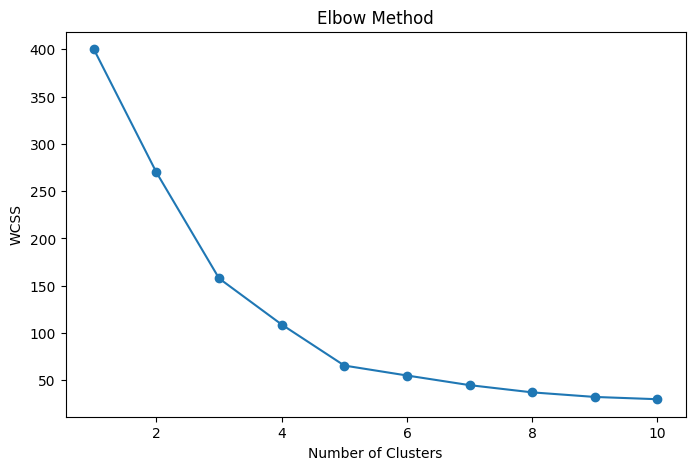

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Estimated_CLV,Cluster
0,1,Male,19,15,39,585,4
1,2,Male,21,15,81,1215,2
2,3,Female,20,16,6,96,4
3,4,Female,23,16,77,1232,2
4,5,Female,31,17,40,680,4


### Applyied K-Means Clustering

Based on the Elbow Method, the optimal number of clusters (K) was selected as 5. The K-Means algorithm assigns each customer to one of these five clusters based on their Annual Income and Spending Score.

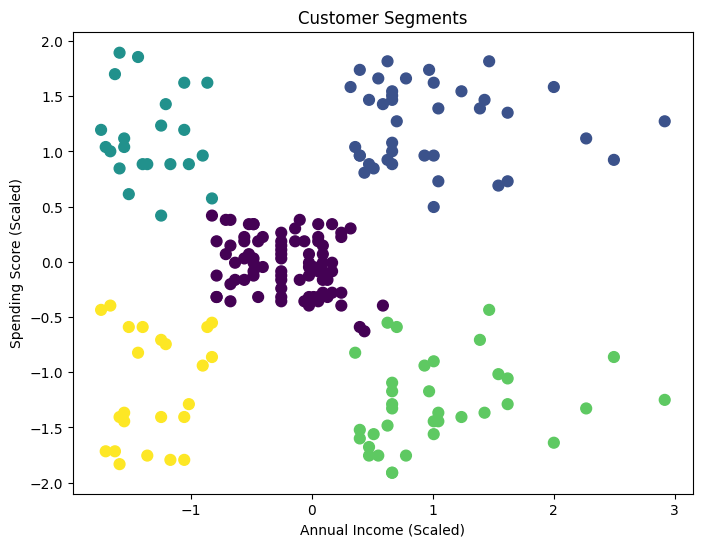

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

### Observation

The scatter plot shows five distinct customer segments based on Annual Income and Spending Score. Customers within the same cluster have similar purchasing behaviour.

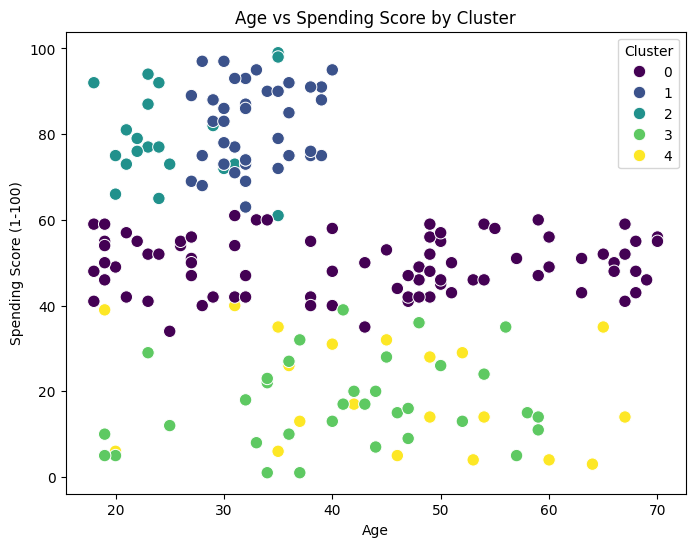

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.title("Age vs Spending Score by Cluster")
plt.show()

### Observation

This plot shows how customers of different age groups are distributed across the clusters based on their spending scores.

In [27]:
cluster_profile = df.groupby("Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


### Cluster Profile

The table displays the average Age, Annual Income, and Spending Score for each customer segment. These averages help understand the characteristics of each cluster.

/tmp/ipykernel_1118/2402119386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


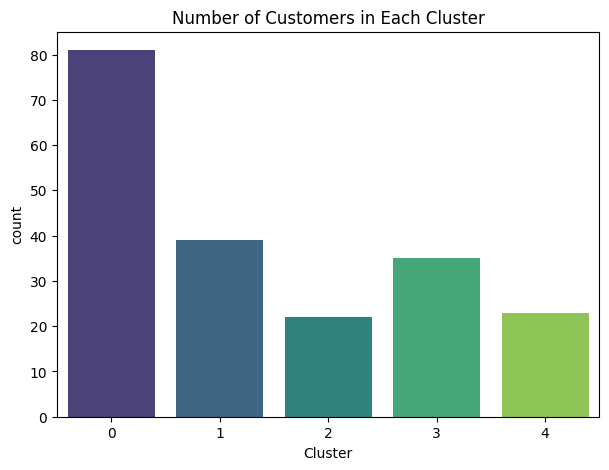

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cluster",
    palette="viridis"
)

plt.title("Number of Customers in Each Cluster")

plt.show()

### Observation

The chart shows the number of customers present in each cluster.

# Insights & Marketing Recommendations

• Cluster 0: High income, high spending customers should receive premium offers and loyalty rewards.

• Cluster 1: Low income, low spending customers can be targeted using discounts and promotional campaigns.

• Cluster 2: Moderate income customers may respond well to personalized product recommendations.

• Cluster 3: High income but low spending customers should be encouraged through exclusive memberships.

• Cluster 4: Young high-spending customers are ideal for new product launches and digital marketing campaigns.

# Conclusion

1. K-Means clustering successfully divided customers into five meaningful groups.

2. Annual Income and Spending Score are the most useful features for customer segmentation.

3. Businesses can use these customer segments to improve marketing strategies, increase customer satisfaction, and maximize revenue.